In [1]:
import pandas as pd
import numpy as np
import tkinter
import matplotlib
import os
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from pathlib import Path

scenario_parent_folder = Path(os.path.abspath('')) / 'logs' /  'unified' / 'buoy'

Ran with 
```
# Independent variables
independent_vars = {
    "nodeXCount" : range(1, 31),
    "nodeZCount": [1],
    "nodeZSpacing": [1],
    "nodeZOffset": list(np.arange(0, -1.8, -0.05)),
    "auvSpeed": [0],
    "propagationModel": ["freshwater"],
    "stopTime": [10*60],  # seconds
    "channelWidth": [1],
    "packetStatsConfig": ["means"],
    "enablePositionLogging": ["true"],
    "powerLoggingConfig": ["short"],
    "scenarioFolderPath": ["unified/buoy/run"]
}

# Dependent variables defined via lambda functions. 
# Each lambda receives a dict with the current independent variables.
dependent_vars = {
    # 1.8 because otherwise we'll have nodes out of range
    "nodeXSpacing": lambda args: 1.8 / (args["nodeXCount"] - 1) if args["nodeXCount"] > 1 else 1,
    "nodeXOffset": lambda args: -args["nodeXSpacing"] * (args["nodeXCount"] - 1) / 2,
    "nodeYCount": lambda args: args["nodeXCount"],
    "nodeYSpacing": lambda args: 1.8 / (args["nodeYCount"] - 1) if args["nodeYCount"] > 1 else 1,
    "nodeYOffset": lambda args: -args["nodeYSpacing"] * (args["nodeYCount"] - 1) / 2,
    "dataRatePHY": lambda args: "OfdmRate1_2MbpsBW1MHz" if args["channelWidth"] == 1 else "OfdmRate7_8MbpsBW2MHz",
}
```

In [2]:
def read_sim_config_file(scenario_folder:Path) -> dict:
    sim_config = {}
    with open(scenario_folder / 'SimConfig.txt') as f:
        for line in f:
            if line.startswith('--'):
                key, value = line.strip().split('=')
                key = key[2:]  # Remove the leading '--'
                
                # Try to convert value to appropriate data type
                try:
                    # First try as int
                    sim_config[key] = int(value)
                except ValueError:
                    try:
                        # Then try as float
                        sim_config[key] = float(value)
                    except ValueError:
                        # Keep as string if not numeric
                        sim_config[key] = value
    return sim_config

In [3]:
# Get all the scenario folders
scenario_folders = sorted([x for x in scenario_parent_folder.iterdir() if x.is_dir()])
print(f"Will load {len(scenario_folders)} scenario runs")

packet_logging_stats_summary_dfs = []
power_state_stats = pd.DataFrame()
for i, scenario_folder in enumerate(scenario_folders):
    sim_config = read_sim_config_file(scenario_folder)
    print(f"[{i+1}/{len(scenario_folders)}] Loading scenario {scenario_folder.name}")

    # Load the packet logging stats
    if (scenario_folder / 'PacketLoggingStatsSummary.csv').exists():
        packet_logging_stats_summary_df = pd.read_csv(scenario_folder / 'PacketLoggingStatsSummary.csv', delimiter=';', index_col=False)
        for key, value in sim_config.items():
            packet_logging_stats_summary_df[key] = value
        packet_logging_stats_summary_dfs.append(packet_logging_stats_summary_df)
    else:
        print(f"PacketLoggingStatsSummary.csv not found in {scenario_folder.name}")
        
    # Load the power state stats
    if (scenario_folder / 'PowerStateStats.csv').exists():
        ps_temp_df = pd.read_csv(scenario_folder / 'PowerStateStats.csv', delimiter=';', index_col=False)
        for col in ['SLEEPTime', 'IDLETime', 'TXTime', 'RXTime', "CCA_BUSYTime", "SWITCHINGTime"]:
            ps_temp_df[col] = ps_temp_df[col].str.replace('ns', '').astype(float)
            # Ignore the APs as we assume they are always on
            power_state_stats.loc[i, col] = ps_temp_df[ps_temp_df['NodeType'] == "STA"][col].mean()
        for key, value in sim_config.items():
            power_state_stats.loc[i, key] = value
    else:
        print(f"PowerStateStats.csv not found in {scenario_folder.name}")
        
packet_logging_stats_summary = pd.concat(packet_logging_stats_summary_dfs)
for col in ['MeanLatencySTAToAP', 'MeanLatencyAPToSTA']:
    packet_logging_stats_summary[col] = abs(packet_logging_stats_summary[col].str.replace('ns', '').astype(float))

Will load 295 scenario runs
[1/295] Loading scenario run_1743115289425596180


[2/295] Loading scenario run_1743115289447295087
[3/295] Loading scenario run_1743115289513457081
[4/295] Loading scenario run_1743115289536678118
[5/295] Loading scenario run_1743115289605659851
[6/295] Loading scenario run_1743115290136094201
[7/295] Loading scenario run_1743115346029380164
[8/295] Loading scenario run_1743115347597175837
[9/295] Loading scenario run_1743115347767973904
[10/295] Loading scenario run_1743115348790978405
[11/295] Loading scenario run_1743115350635427701
[12/295] Loading scenario run_1743115351273643937
[13/295] Loading scenario run_1743115401360478107
[14/295] Loading scenario run_1743115404459899149
[15/295] Loading scenario run_1743115405801444018
[16/295] Loading scenario run_1743115408012105745
[17/295] Loading scenario run_1743115409491138446
[18/295] Loading scenario run_1743115410130321740
[19/295] Loading scenario run_1743115460636005234
[20/295] Loading scenario run_1743115462329727832
[21/295] Loading scenario run_1743115463296685355
[22/295]

In [4]:
packet_logging_stats_summary

,CountPacketsSentSTAToAP,CountPacketsSentAPToSTA,MeanPacketSizeSTAToAP,MeanPacketSizeAPToSTA,MeanTxBeginCountSTAToAP,MeanTxBeginCountAPToSTA,MeanRxEndCountSTAToAP,MeanRxEndCountAPToSTA,MeanRxDropCountSTAToAP,MeanRxDropCountAPToSTA,...,packetStatsConfig,enablePositionLogging,powerLoggingConfig,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYCount,nodeYSpacing,nodeYOffset,dataRatePHY
0,15278,17972,625.896,89.9996,2,1,2,1,0,0,...,means,true,short,unified/buoy/run,1.000000,0.0,1,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
0,15278,17972,625.896,89.9996,2,1,2,1,0,0,...,means,true,short,unified/buoy/run,1.000000,0.0,1,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
0,15278,17972,625.896,89.9996,2,1,2,1,0,0,...,means,true,short,unified/buoy/run,1.000000,0.0,1,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
0,15278,17972,625.896,89.9996,2,1,2,1,0,0,...,means,true,short,unified/buoy/run,1.000000,0.0,1,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
0,15520,18106,625.830,89.9986,2,1,2,1,0,0,...,means,true,short,unified/buoy/run,1.000000,0.0,1,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,91,84,102.000,93.0000,6,6,0,0,6,6,...,means,true,short,unified/buoy/run,0.257143,-0.9,8,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
0,92,76,102.000,93.0000,6,6,0,0,6,5,...,means,true,short,unified/buoy/run,0.257143,-0.9,8,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
0,58,57,102.000,93.0000,6,6,0,0,6,5,...,means,true,short,unified/buoy/run,0.257143,-0.9,8,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
0,5939,9166,583.861,89.9260,12,1,2,1,9,0,...,means,true,short,unified/buoy/run,0.225000,-0.9,9,0.225000,-0.9,OfdmRate1_2MbpsBW1MHz


In [5]:
power_state_stats

,SLEEPTime,IDLETime,TXTime,RXTime,CCA_BUSYTime,SWITCHINGTime,nodeXCount,nodeZCount,nodeZSpacing,nodeZOffset,...,packetStatsConfig,enablePositionLogging,powerLoggingConfig,scenarioFolderPath,nodeXSpacing,nodeXOffset,nodeYCount,nodeYSpacing,nodeYOffset,dataRatePHY
0,1.561362e+11,1.948880e+11,1.689495e+11,8.002992e+10,0.000000e+00,0.0,1.0,1.0,1.0,-0.05,...,means,true,short,unified/buoy/run,1.000000,0.0,1.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
1,1.561362e+11,1.948880e+11,1.689495e+11,8.002992e+10,0.000000e+00,0.0,1.0,1.0,1.0,-0.10,...,means,true,short,unified/buoy/run,1.000000,0.0,1.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
2,1.561361e+11,1.948881e+11,1.689495e+11,8.002992e+10,0.000000e+00,0.0,1.0,1.0,1.0,-0.15,...,means,true,short,unified/buoy/run,1.000000,0.0,1.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
3,1.561360e+11,1.948882e+11,1.689495e+11,8.002992e+10,0.000000e+00,0.0,1.0,1.0,1.0,-0.25,...,means,true,short,unified/buoy/run,1.000000,0.0,1.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
4,1.540925e+11,1.936171e+11,1.714610e+11,8.083292e+10,0.000000e+00,0.0,1.0,1.0,1.0,0.00,...,means,true,short,unified/buoy/run,1.000000,0.0,1.0,1.000000,0.0,OfdmRate1_2MbpsBW1MHz
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
282,0.000000e+00,5.517520e+10,3.196870e+10,5.050841e+11,7.769597e+09,0.0,8.0,1.0,1.0,-1.55,...,means,true,short,unified/buoy/run,0.257143,-0.9,8.0,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
283,0.000000e+00,5.512694e+10,3.307053e+10,5.041881e+11,7.611947e+09,0.0,8.0,1.0,1.0,-1.60,...,means,true,short,unified/buoy/run,0.257143,-0.9,8.0,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
285,0.000000e+00,5.508619e+10,3.497586e+10,5.024225e+11,7.513499e+09,0.0,8.0,1.0,1.0,-1.70,...,means,true,short,unified/buoy/run,0.257143,-0.9,8.0,0.257143,-0.9,OfdmRate1_2MbpsBW1MHz
287,8.362421e+10,2.050232e+11,1.154697e+10,2.927714e+11,7.032068e+09,0.0,9.0,1.0,1.0,0.00,...,means,true,short,unified/buoy/run,0.225000,-0.9,9.0,0.225000,-0.9,OfdmRate1_2MbpsBW1MHz


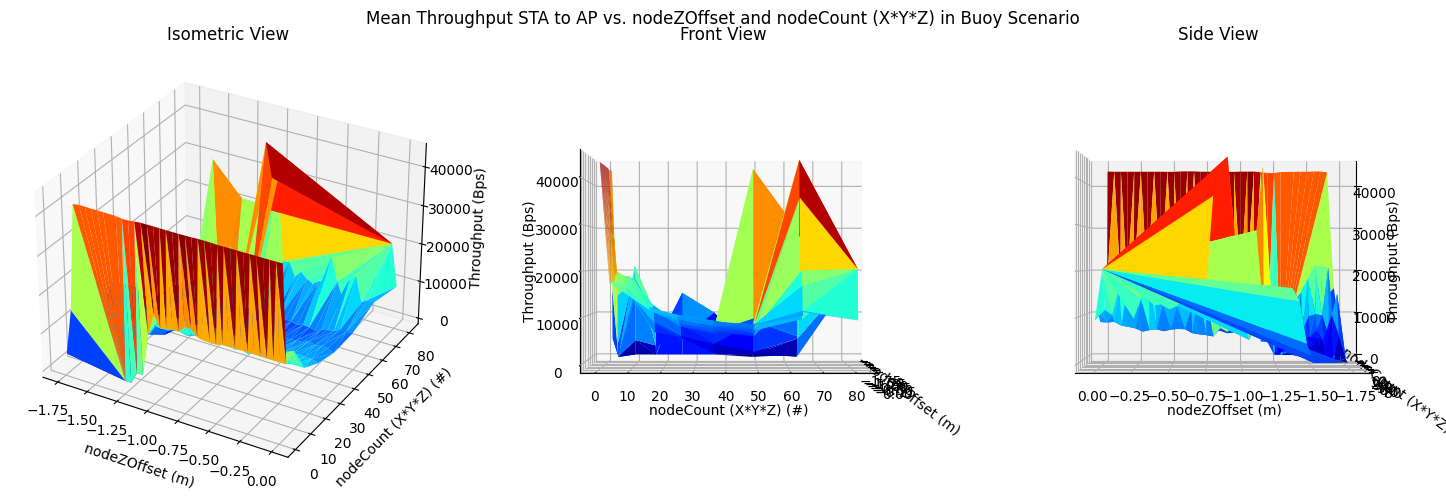

In [6]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Throughput STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Common data points
x_data = packet_logging_stats_summary['nodeZOffset']
y_data = packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount']
z_data = packet_logging_stats_summary['MeanThroughputSTAToAP']

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Throughput (Bps)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Throughput (Bps)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Throughput (Bps)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

/home/research/.local/lib/python3.8/site-packages/pandas/core/series.py:917: RuntimeWarning: invalid value encountered in cast
  arr = np.asarray(values, dtype=dtype)


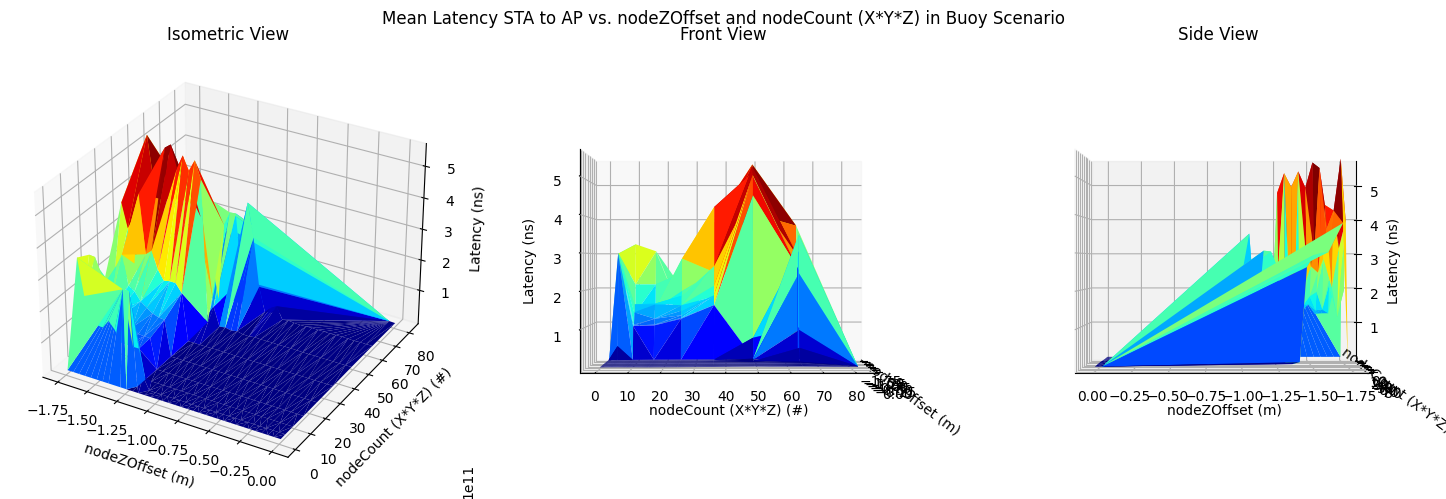

In [7]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean Latency STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Common data points
x_data = packet_logging_stats_summary['nodeZOffset']
y_data = packet_logging_stats_summary['nodeXCount'] * packet_logging_stats_summary['nodeYCount'] * packet_logging_stats_summary['nodeZCount']
z_data = packet_logging_stats_summary['MeanLatencySTAToAP']

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Latency (ns)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Latency (ns)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Latency (ns)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()

In [8]:
# Convert time from ns to h
for col in filter(lambda x: x.endswith('Time'), power_state_stats.columns):
    power_state_stats[col] = power_state_stats[col] / 1e9 / 3600

# Multiply the time by the power consumption of each state
# Constants from https://www.nsnam.org/docs/release/3.23/doxygen/classns3_1_1_wifi_radio_energy_model.html
voltage = 3
power_state_stats['RXPower'] = power_state_stats['RXTime'] * voltage * 0.313
power_state_stats['TXPower'] = power_state_stats['TXTime'] * voltage * 0.38
power_state_stats['IDLEPower'] = power_state_stats['IDLETime'] * voltage * 0.273
power_state_stats['SLEEPPower'] = power_state_stats['SLEEPTime'] * voltage * 0.033
power_state_stats['CCA_BUSYPower'] = power_state_stats['CCA_BUSYTime'] * voltage * 0.273
power_state_stats['SWITCHINGPower'] = power_state_stats['SWITCHINGTime'] * voltage * 0.273
power_state_stats['TotalPower'] = power_state_stats['RXPower'] + power_state_stats['TXPower'] + power_state_stats['IDLEPower'] + power_state_stats['SLEEPPower'] + power_state_stats['CCA_BUSYPower'] + power_state_stats['SWITCHINGPower']

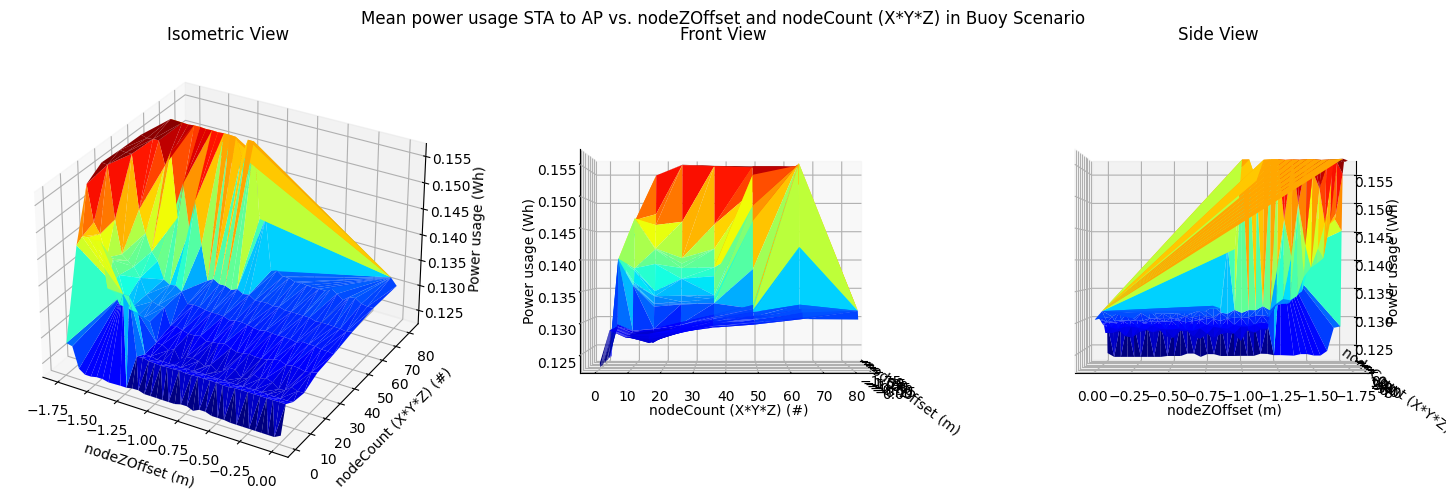

In [9]:
fig = plt.figure(figsize=(15, 5))
fig.suptitle('Mean power usage STA to AP vs. nodeZOffset and nodeCount (X*Y*Z) in Buoy Scenario')

# Common data points
x_data = power_state_stats['nodeZOffset']
y_data = power_state_stats['nodeXCount'] * power_state_stats['nodeYCount'] * power_state_stats['nodeZCount']
z_data = power_state_stats['TotalPower']

# Isometric view (default 3D view)
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax1.set_xlabel('nodeZOffset (m)')
ax1.set_ylabel('nodeCount (X*Y*Z) (#)')
ax1.set_zlabel('Power usage (Wh)')
ax1.set_title('Isometric View')

# Front view (looking at X-Z plane)
ax2 = fig.add_subplot(132, projection='3d')
ax2.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax2.set_xlabel('nodeZOffset (m)')
ax2.set_ylabel('nodeCount (X*Y*Z) (#)')
ax2.set_zlabel('Power usage (Wh)')
ax2.view_init(elev=0, azim=0)
ax2.set_title('Front View')

# Side view (looking at Y-Z plane)
ax3 = fig.add_subplot(133, projection='3d')
ax3.plot_trisurf(x_data, y_data, z_data, cmap='jet')
ax3.set_xlabel('nodeZOffset (m)')
ax3.set_ylabel('nodeCount (X*Y*Z) (#)')
ax3.set_zlabel('Power usage (Wh)')
ax3.view_init(elev=0, azim=90)
ax3.set_title('Side View')

plt.tight_layout()
plt.show()